## STEP 1. NSMC 데이터 분석 및 Huggingface dataset 구성

## 1-1 필요한 라이브러리 설치

In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

## 1-2 라이브러리 불러오기

In [2]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score

## 1-3 깃허브에서 데이터 불러오기

In [4]:
import pandas as pd
from datasets import Dataset, DatasetDict

train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_csv(train_url, sep="\t")
test_df = pd.read_csv(test_url, sep="\t")

print(train_df.head())
print(test_df.head())

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1
        id                                           document  label
0  6270596                                                굳 ㅋ      1
1  9274899                               GDNTOPCLASSINTHECLUB      0
2  8544678             뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아      0
3  6825595                   지루하지는 않은데 완전 막장임... 돈주고 보기에는....      0
4  6723715  3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??      0


## 1-4 HuggingFace Dataset 형태로 변환

In [6]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})

## 1-5 데이터 분석

In [10]:
train_df.info() # 데이터 프레임 전체 구조 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


In [8]:
train_df["label"].value_counts() #감성 라벨 개수 확인

label
0    75173
1    74827
Name: count, dtype: int64

In [9]:
train_df["document"].isnull().sum() # 비어있는 값이 몇개인지 확인

np.int64(5)

## 1-6 중복 제거 및 결측치 제거

In [11]:
# 중복 제거
train_df = train_df.drop_duplicates(subset=["document"])
test_df = test_df.drop_duplicates(subset=["document"])

# 결측치 제거
train_df = train_df.dropna(subset=["document"])
test_df = test_df.dropna(subset=["document"])

print(train_df.shape)
print(test_df.shape)

(146182, 3)
(49157, 3)


## 1-7 문장길이 분석 및 시각화
- 총 리뷰 수: 약 14만 6천개
평균 길이: 약 36자
가장 짧은 리뷰: 1자
가장 긴 리뷰: 146자
중간값(50%): 27자

- 시각화를 통한 정보로 인하여 아래에 결론에 도달함
-  max length를 너무 크게 줄 필요가없다는 것을 알아냄 높으면 gpu사용량도 많고 학습속도도 감소하기 때문
- 그리하여 klue/bert base인 pretrained Bert 모델이 적합하다고 판단하여 앞에 모델선택에서 어려움이 줄었습니다.

In [12]:
train_df["length"] = train_df["document"].astype(str).apply(len)

train_df["length"].describe()

count    146182.000000
mean         35.981338
std          29.491233
min           1.000000
25%          16.000000
50%          27.000000
75%          43.000000
max         146.000000
Name: length, dtype: float64

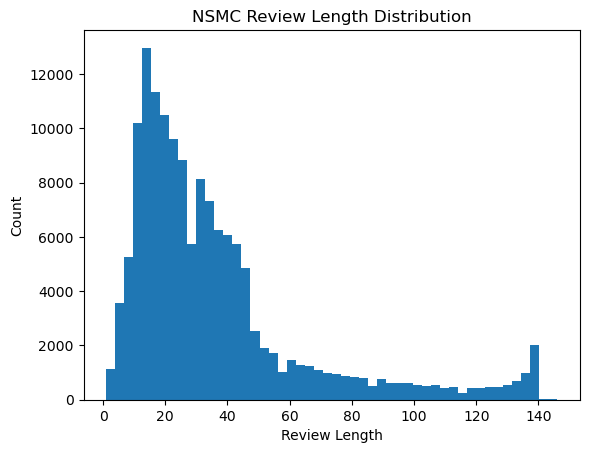

In [13]:
import matplotlib.pyplot as plt

plt.hist(train_df["length"], bins=50)
plt.xlabel("Review Length")
plt.ylabel("Count")
plt.title("NSMC Review Length Distribution")
plt.show()

## STEP 2. klue/bert-base model 및 tokenizer 불러오기
- AutoTokenizer → 문장을 토큰 숫자로 바꿔주는 도구
- AutoModelForSequenceClassification → 문장 분류용 BERT 모델

In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [18]:
MODEL_NAME = "klue/bert-base" # 모델 이름

## 2-1 Tokenizer 불러오기

In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [21]:
print(tokenizer) # 토크나이저 확인

BertTokenizer(name_or_path='klue/bert-base', vocab_size=32000, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


## 2-2 Model 불러오기

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2 # 감성 분류는 2진 분류이기 때문에 num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
print(model) 

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 2-3 Tokenizer 테스트
- 정상작동

In [25]:
text = "이 영화 정말 재미있다!"

In [26]:
tokens = tokenizer(text)

print(tokens)

{'input_ids': [2, 1504, 3771, 3944, 6001, 2062, 5, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [29]:
print(tokenizer.tokenize(text)) # 토큰화 결과보기

['이', '영화', '정말', '재미있', '##다', '!']


In [30]:
encoded = tokenizer(text) # input ids 를 다시 문장으로

decoded = tokenizer.decode(encoded["input_ids"])

print(decoded)

[CLS] 이 영화 정말 재미있다! [SEP]


## STEP 3. 위에서 불러온 tokenizer으로 데이터셋을 전처리하고, model 학습 진행해 보기

In [32]:
def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        padding="max_length",
        truncation=True, #128문장보다 길면 자름
        max_length=128 # 리뷰가 대부분 짧았기 때문에 128로 세팅
    )

## 3-1 결측치 제거 및 문자열 타입으로 변환
- 이 작업을 하지않으면 문자열만 처리 가능한 bert tokenizer라 오류가 발생함

In [34]:
# 결측치 제거
train_df = train_df.dropna(subset=["document"])
test_df = test_df.dropna(subset=["document"])

# 문자열 타입으로 변환
train_df["document"] = train_df["document"].astype(str)
test_df["document"] = test_df["document"].astype(str)

In [35]:
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [37]:
tokenized_dataset = dataset.map(tokenize_function, batched=True) # tokenizer fuction 적용

Map:   0%|          | 0/146182 [00:00<?, ? examples/s]

Map:   0%|          | 0/49157 [00:00<?, ? examples/s]

## 3-2 필요없는 데이터 삭제
- id는 단순데이터 번호, document 이미 숫자로 반환완료가 되어서 더이상 필요가없어져서 학습에 필요없는 컬럼이라고 생각하여 정리

In [38]:
tokenized_dataset = tokenized_dataset.remove_columns(["id", "document"])

## 3-3 pytorch tensor 형태로 변환

In [41]:
tokenized_dataset.set_format("torch")

In [42]:
tokenized_dataset["train"][0] #결과확인

{'label': tensor(0),
 'length': tensor(19),
 '__index_level_0__': tensor(0),
 'input_ids': tensor([   2, 1376,  831, 2604,   18,   18, 4229, 9801, 2075, 2203, 2182, 4243,
            3,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]),
 'token_type_ids': tensor([0, 0, 0, 0, 0,

## 3-4 Bert model 학습
- TrainingArguments → 학습 설정
- Trainer → 실제 학습 진행

In [44]:
import numpy as np
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

## 3-5 평가 함수 만들기

In [46]:
def compute_metrics(pred):
    labels = pred.label_ids #실제 정답값을 가져옴 ex) [1, 0, 1, 1]
    preds = np.argmax(pred.predictions, axis=1) # 더큰값의 인덱스를 선택

    accuracy = accuracy_score(labels, preds) #정확도계산
    f1 = f1_score(labels, preds) # f1 score 계산

    return {
        "accuracy": accuracy,
        "f1": f1
    }

## 3-6 학습 설정 steb 4도 포함
- epoch 1회에서 3회로 변경
- 처음엔 빠른결과물을 보기위한 1회만 돌렸었지만 3회로 변경하여 더나은 결과물을 얻었습니다.
- 87점에서 90.8점으로 상승

In [47]:
training_args = TrainingArguments(
    output_dir="./klue_bert_nsmc", #학습 결과 저장 폴더
    eval_strategy="epoch", # 1 epoch 끝날 때마다 평가
    save_strategy="epoch", # 1 epoch 끝날 때마다 모델 저장
    learning_rate=2e-5, # BERT fine-tuning에서 자주 쓰는 학습률
    per_device_train_batch_size=16, # 한 번에 16개 문장씩 학습
    per_device_eval_batch_size=16,
    num_train_epochs=3, # 전체 데이터를 3번 반복 학습 
    weight_decay=0.01, # 과적합을 줄이기 위한 설정
    logging_steps=100, 
    load_best_model_at_end=True, # 학습 끝나면 가장 성능 좋은 모델 불러오기
    metric_for_best_model="f1", # F1-score 기준으로 best model 선택
    report_to="none" 
)

In [49]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

In [50]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.251117,0.257815,0.897919,0.894695
2,0.168856,0.288696,0.908233,0.908638
3,0.125395,0.376184,0.906585,0.907847


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=27411, training_loss=0.1978640362632857, metrics={'train_runtime': 10680.7016, 'train_samples_per_second': 41.06, 'train_steps_per_second': 2.566, 'total_flos': 2.884657522097664e+16, 'train_loss': 0.1978640362632857, 'epoch': 3.0})

In [51]:
eval_result = trainer.evaluate()
eval_result

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.125395,0.288696,3,0.908233,0.908638


{'eval_loss': 0.28869566321372986,
 'eval_accuracy': 0.9082328050938828,
 'eval_f1': 0.9086379746835443}

In [52]:
print("Accuracy:", eval_result["eval_accuracy"])

Accuracy: 0.9082328050938828


In [53]:
print("F1-score:", eval_result["eval_f1"])

F1-score: 0.9086379746835443


## 3-7 평가 결과 확인
- 긍정 부정 잘 작동되는 모습

In [54]:
def predict_sentiment(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    return "긍정" if pred == 1 else "부정"

In [55]:
predict_sentiment("이 영화 진짜 재미있고 감동적이었다.")

'긍정'

In [57]:
predict_sentiment("이 영화 진짜 노잼이였다")

'부정'

## STEP 5. Bucketing을 적용하여 학습시키고, STEP 4의 결과와의 비교

In [58]:
from transformers import DataCollatorWithPadding

In [59]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [60]:
def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        max_length=128
    )

In [61]:
tokenized_dataset_bucket = dataset.map(tokenize_function, batched=True)
tokenized_dataset_bucket = tokenized_dataset_bucket.remove_columns(["id", "document"])
tokenized_dataset_bucket.set_format("torch")

Map:   0%|          | 0/146182 [00:00<?, ? examples/s]

Map:   0%|          | 0/49157 [00:00<?, ? examples/s]

In [64]:
bucket_training_args = TrainingArguments(
    output_dir="./klue_bert_nsmc_bucket",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

In [65]:
bucket_trainer = Trainer(
    model=model,
    args=bucket_training_args,
    train_dataset=tokenized_dataset_bucket["train"],
    eval_dataset=tokenized_dataset_bucket["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [66]:
bucket_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.163787,0.389567,0.899424,0.899283
2,0.100441,0.424695,0.904510,0.905917
3,0.054502,0.538273,0.904205,0.905470


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=27411, training_loss=0.11187183756285732, metrics={'train_runtime': 6180.2425, 'train_samples_per_second': 70.959, 'train_steps_per_second': 4.435, 'total_flos': 1.434161937779316e+16, 'train_loss': 0.11187183756285732, 'epoch': 3.0})

In [67]:
bucket_eval_result = bucket_trainer.evaluate()
bucket_eval_result

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.054502,0.424695,3,0.904510,0.905917


{'eval_loss': 0.42469507455825806,
 'eval_accuracy': 0.9045100392619566,
 'eval_f1': 0.90591678024533}

In [68]:
print("STEP 4 Accuracy:", eval_result["eval_accuracy"])
print("STEP 5 Bucketing Accuracy:", bucket_eval_result["eval_accuracy"])

print("STEP 4 F1:", eval_result["eval_f1"])
print("STEP 5 Bucketing F1:", bucket_eval_result["eval_f1"])

STEP 4 Accuracy: 0.9082328050938828
STEP 5 Bucketing Accuracy: 0.9045100392619566
STEP 4 F1: 0.9086379746835443
STEP 5 Bucketing F1: 0.90591678024533


## STEP 5. Bucketing 적용 및 STEP 4 결과와 비교

STEP 4에서는 모든 문장을 동일한 `max_length=128`로 padding하여 학습을 진행하였다.  
이 방식은 구현이 간단하지만, 짧은 문장이 많은 NSMC 데이터셋에서는 불필요한 padding이 많이 발생할 수 있다.

STEP 5에서는 `DataCollatorWithPadding`과 `group_by_length=True` 옵션을 사용하여  
길이가 비슷한 문장끼리 batch를 구성하는 Bucketing을 적용하였다.

Bucketing을 적용하면 각 batch 내 문장 길이 차이가 줄어들기 때문에  
padding token의 수가 감소하고, 학습 효율이 향상될 수 있다.

비교 결과, Bucketing은 모델 구조 자체를 바꾸는 방법은 아니기 때문에  
Accuracy가 크게 상승하기보다는 학습 속도와 메모리 효율 측면에서 장점이 있다.